Import all libraries

In [7]:
import joblib
import os
import glob
import sys
sys.path.append(os.path.abspath(os.path.join('..','..')))
from config import DATASETS,MODELS_PIPELINES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from custom_transfrom import LabelDecoderWrapper
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

select latest csv file path from Datasets folder

In [8]:


def select_latest_file():
    file_paths = glob.glob(os.path.join(DATASETS,"*.csv"))
    if not file_paths:
        return None
    else:
        latest = max(file_paths,key=os.path.getmtime)
        df = pd.read_csv(latest)
        return df

convert csv file data into Dataframe

In [9]:
# load dataframe
try:
    df = select_latest_file()
    print(df.head(5))
except:
    print("no file avilable insdie DATASET folder")

   Patient_ID  Age  Gender            Symptom_1    Symptom_2 Symptom_3  \
0           1   74    Male              Fatigue  Sore throat     Fever   
1           2   66  Female          Sore throat      Fatigue     Cough   
2           3   32    Male            Body ache  Sore throat   Fatigue   
3           4   21  Female  Shortness of breath     Headache     Cough   
4           5   53    Male           Runny nose  Sore throat   Fatigue   

   Heart_Rate_bpm  Body_Temperature_C Blood_Pressure_mmHg  \
0              69                39.4              132/91   
1              95                39.0              174/98   
2              77                36.8              136/60   
3              72                38.9              147/82   
4             100                36.6             109/106   

   Oxygen_Saturation_pct Diagnosis  Severity       Treatment_Plan  
0                     94       Flu  Moderate  Medication and rest  
1                     98   Healthy      Mild      Re

check dataframe

In [10]:
df.head()

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_pct,Diagnosis,Severity,Treatment_Plan
0,1,74,Male,Fatigue,Sore throat,Fever,69,39.4,132/91,94,Flu,Moderate,Medication and rest
1,2,66,Female,Sore throat,Fatigue,Cough,95,39.0,174/98,98,Healthy,Mild,Rest and fluids
2,3,32,Male,Body ache,Sore throat,Fatigue,77,36.8,136/60,96,Healthy,Mild,Rest and fluids
3,4,21,Female,Shortness of breath,Headache,Cough,72,38.9,147/82,99,Healthy,Mild,Rest and fluids
4,5,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,109/106,92,Healthy,Mild,Rest and fluids


Separate Target features and remaning features

In [11]:

X = df
y = df["Diagnosis"]

Convert Target features into Labelencoding for ml models

In [12]:

le = LabelEncoder()
y = le.fit_transform(df["Diagnosis"])

Separate x and y into train and test 

In [13]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(np.unique_counts(y))
print(df["Diagnosis"].value_counts())


UniqueCountsResult(values=array([0, 1, 2, 3, 4]), counts=array([ 334,  163,  292, 1167,   44]))
Diagnosis
Healthy       1167
Bronchitis     334
Flu            292
Cold           163
Pneumonia       44
Name: count, dtype: int64


Load Data cleaning pipeline 

In [14]:

file_name = "Disease_data_cleaning_pipeline.pkl"
pipeline_path = os.path.join(MODELS_PIPELINES,file_name)
pipeline_data_clean = joblib.load(pipeline_path)

Clean x_train and x_test for ml models

In [15]:
# Apply pipeline transform
pipeline_x_train = pipeline_data_clean.transform(x_train_raw)
pipeline_x_test = pipeline_data_clean.transform(x_test_raw)
clean_x_train = pd.DataFrame(pipeline_x_train, columns=pipeline_data_clean.get_feature_names_out())
clean_x_test = pd.DataFrame(pipeline_x_test, columns=pipeline_data_clean.get_feature_names_out())


In [16]:
clean_x_train.columns.tolist()

['bp__systolic',
 'bp__diastolic',
 'binary__Gender',
 'nominal__Symptom_1_Body ache',
 'nominal__Symptom_1_Cough',
 'nominal__Symptom_1_Fatigue',
 'nominal__Symptom_1_Fever',
 'nominal__Symptom_1_Headache',
 'nominal__Symptom_1_Runny nose',
 'nominal__Symptom_1_Shortness of breath',
 'nominal__Symptom_1_Sore throat',
 'nominal__Symptom_2_Body ache',
 'nominal__Symptom_2_Cough',
 'nominal__Symptom_2_Fatigue',
 'nominal__Symptom_2_Fever',
 'nominal__Symptom_2_Headache',
 'nominal__Symptom_2_Runny nose',
 'nominal__Symptom_2_Shortness of breath',
 'nominal__Symptom_2_Sore throat',
 'nominal__Symptom_3_Body ache',
 'nominal__Symptom_3_Cough',
 'nominal__Symptom_3_Fatigue',
 'nominal__Symptom_3_Fever',
 'nominal__Symptom_3_Headache',
 'nominal__Symptom_3_Runny nose',
 'nominal__Symptom_3_Shortness of breath',
 'nominal__Symptom_3_Sore throat',
 'continue__Age',
 'continue__Heart_Rate_bpm',
 'continue__Body_Temperature_C',
 'continue__Oxygen_Saturation_pct']

In [17]:
clean_x_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   bp__systolic                            1600 non-null   float64
 1   bp__diastolic                           1600 non-null   float64
 2   binary__Gender                          1600 non-null   float64
 3   nominal__Symptom_1_Body ache            1600 non-null   float64
 4   nominal__Symptom_1_Cough                1600 non-null   float64
 5   nominal__Symptom_1_Fatigue              1600 non-null   float64
 6   nominal__Symptom_1_Fever                1600 non-null   float64
 7   nominal__Symptom_1_Headache             1600 non-null   float64
 8   nominal__Symptom_1_Runny nose           1600 non-null   float64
 9   nominal__Symptom_1_Shortness of breath  1600 non-null   float64
 10  nominal__Symptom_1_Sore throat          1600 non-null   float64
 11  no

Bronchitis = 0 , Cold = 1, Flu = 2, Healthy = 3 ,pneumonia 4

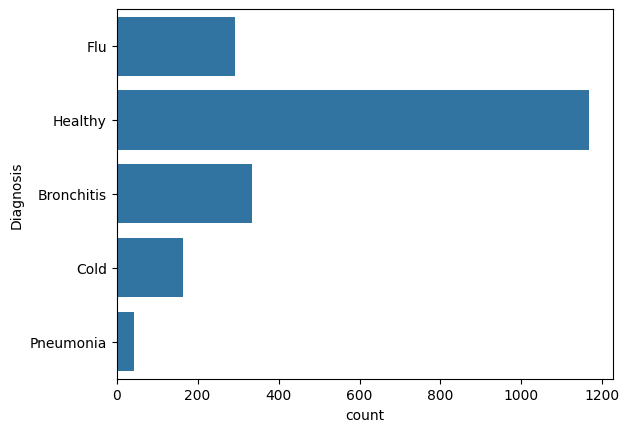

In [18]:
sns.countplot(df["Diagnosis"])
plt.show()

Random forest classifier ML model

In [19]:
model1 = RandomForestClassifier(n_estimators=500,max_depth=10,)
model1.fit(clean_x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

predict output using model1

In [20]:
pred_model1_test = model1.predict(clean_x_test)
pred_model1_test

array([1, 3, 2, 2, 3, 0, 3, 3, 3, 2, 3, 3, 3, 0, 3, 3, 0, 3, 3, 0, 3, 3,
       2, 2, 3, 3, 3, 2, 1, 0, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2,
       1, 3, 3, 2, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 0,
       3, 0, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 2, 3, 0, 2, 2,
       3, 3, 0, 3, 2, 3, 3, 0, 0, 3, 1, 3, 3, 3, 3, 2, 2, 2, 3, 3, 0, 3,
       3, 2, 1, 0, 3, 3, 0, 0, 3, 3, 3, 1, 3, 3, 3, 2, 2, 3, 3, 3, 3, 2,
       2, 2, 3, 3, 2, 0, 1, 2, 3, 2, 0, 0, 0, 3, 3, 3, 2, 3, 0, 1, 3, 0,
       3, 3, 0, 3, 2, 3, 3, 3, 3, 1, 3, 3, 0, 3, 1, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 0, 0, 1, 2, 2, 1, 3,
       3, 3, 0, 3, 0, 1, 3, 3, 3, 1, 3, 1, 0, 0, 1, 1, 3, 3, 2, 3, 0, 1,
       0, 3, 3, 3, 2, 3, 3, 1, 2, 3, 1, 0, 0, 3, 3, 3, 3, 0, 0, 3, 0, 3,
       2, 3, 3, 3, 3, 3, 3, 2, 3, 1, 0, 2, 3, 3, 3, 3, 3, 0, 0, 3, 3, 3,
       0, 3, 3, 1, 3, 3, 0, 0, 3, 3, 3, 2, 3, 3, 3, 2, 1, 2, 3, 3, 1, 0,
       3, 2, 1, 3, 3, 1, 2, 3, 3, 2, 0, 3, 0, 3, 3,

check test data classification report

In [21]:
print(classification_report(y_test,pred_model1_test))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        67
           1       1.00      0.94      0.97        33
           2       0.89      0.97      0.93        58
           3       0.98      1.00      0.99       233
           4       1.00      0.11      0.20         9

    accuracy                           0.97       400
   macro avg       0.97      0.80      0.82       400
weighted avg       0.97      0.97      0.96       400



Check train data classification report

In [22]:
pred_model1_train = model1.predict(clean_x_train)
print(classification_report(y_train,pred_model1_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       267
           1       1.00      1.00      1.00       130
           2       1.00      1.00      1.00       234
           3       1.00      1.00      1.00       934
           4       1.00      1.00      1.00        35

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



Check model predication using Confusion matrix

In [23]:
cm1= confusion_matrix(y_test,pred_model1_test)
cm1

array([[ 67,   0,   0,   0,   0],
       [  0,  31,   0,   2,   0],
       [  1,   0,  56,   1,   0],
       [  0,   0,   0, 233,   0],
       [  0,   0,   7,   1,   1]])

Check model learning rate using ROC_AUC_SCORE

In [24]:
y_te_roc1 = model1.predict_proba(clean_x_test)
y_tr_roc1 = model1.predict_proba(clean_x_train)
print(roc_auc_score(y_test,y_te_roc1,multi_class='ovr',average='macro'))
print(roc_auc_score(y_train,y_tr_roc1,multi_class='ovr',average='macro'))

0.9982966296273024
1.0


Check Model accuracy using cross validation score

In [25]:
scores = cross_val_score(model1,clean_x_train,y_train,cv=5)
scores.mean()

np.float64(0.9668749999999999)

XGBoost model

In [26]:
# Define model
model2 = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    random_state=42
)

Fit model2 with train data

In [27]:

# Fit model
model2.fit(clean_x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Predict output using model for both train and test data

In [28]:
# Predictions
y_tes_pred2 = model2.predict(clean_x_test)
y_tra_pred2 = model2.predict(clean_x_train)

Check model classification Report and confusion Matrix Test data

In [29]:
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_tes_pred2, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_tes_pred2))


Classification Report:
               precision    recall  f1-score   support

  Bronchitis       0.96      1.00      0.98        67
        Cold       1.00      1.00      1.00        33
         Flu       0.95      0.97      0.96        58
     Healthy       1.00      1.00      1.00       233
   Pneumonia       1.00      0.44      0.62         9

    accuracy                           0.98       400
   macro avg       0.98      0.88      0.91       400
weighted avg       0.98      0.98      0.98       400

Confusion Matrix:
 [[ 67   0   0   0   0]
 [  0  33   0   0   0]
 [  2   0  56   0   0]
 [  0   0   0 233   0]
 [  1   0   3   1   4]]


Check model classification Report and confusion Matrix Train data

In [30]:
print("Classification Report:\n", classification_report(y_train, y_tra_pred2, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_tra_pred2))


Classification Report:
               precision    recall  f1-score   support

  Bronchitis       0.99      1.00      0.99       267
        Cold       1.00      1.00      1.00       130
         Flu       1.00      0.99      0.99       234
     Healthy       1.00      1.00      1.00       934
   Pneumonia       1.00      0.94      0.97        35

    accuracy                           1.00      1600
   macro avg       1.00      0.99      0.99      1600
weighted avg       1.00      1.00      1.00      1600

Confusion Matrix:
 [[267   0   0   0   0]
 [  0 130   0   0   0]
 [  2   0 232   0   0]
 [  0   0   0 934   0]
 [  1   0   1   0  33]]


Check Model learning rate using Roc_AUC_score

In [31]:
y_te_roc2 = model2.predict_proba(clean_x_test)
y_tr_roc2 = model2.predict_proba(clean_x_train)

In [32]:
print(roc_auc_score(y_test,y_te_roc2,multi_class='ovr',average='macro'))

0.9989027416116503


In [33]:
print(roc_auc_score(y_train,y_tr_roc2,multi_class='ovr',average='macro'))

0.9999987486078261


Check model accuracy

In [34]:
scores = cross_val_score(model2,clean_x_train,y_train,cv=5)
scores.mean()

np.float64(0.9862500000000001)

Select 2 model and make pipeline for data_cleaning and model2

In [37]:
# main pipeline
final_full_ml_pipeline = Pipeline([
    ("preprocessing",pipeline_data_clean),
    ("xgboost",model2)
])

In [38]:
final_full_ml_pipeline.fit(x_train_raw,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('xgboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bp', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [41]:
pipeline_data_clean.get_feature_names_out()

array(['bp__systolic', 'bp__diastolic', 'binary__Gender',
       'nominal__Symptom_1_Body ache', 'nominal__Symptom_1_Cough',
       'nominal__Symptom_1_Fatigue', 'nominal__Symptom_1_Fever',
       'nominal__Symptom_1_Headache', 'nominal__Symptom_1_Runny nose',
       'nominal__Symptom_1_Shortness of breath',
       'nominal__Symptom_1_Sore throat', 'nominal__Symptom_2_Body ache',
       'nominal__Symptom_2_Cough', 'nominal__Symptom_2_Fatigue',
       'nominal__Symptom_2_Fever', 'nominal__Symptom_2_Headache',
       'nominal__Symptom_2_Runny nose',
       'nominal__Symptom_2_Shortness of breath',
       'nominal__Symptom_2_Sore throat', 'nominal__Symptom_3_Body ache',
       'nominal__Symptom_3_Cough', 'nominal__Symptom_3_Fatigue',
       'nominal__Symptom_3_Fever', 'nominal__Symptom_3_Headache',
       'nominal__Symptom_3_Runny nose',
       'nominal__Symptom_3_Shortness of breath',
       'nominal__Symptom_3_Sore throat', 'continue__Age',
       'continue__Heart_Rate_bpm', 'continue__

Make File path name inside Model piplines folder

In [42]:
file_name = f"Disease_diagnosis_ml_pipeline.pkl"
Pipeline_save_path = os.path.join(MODELS_PIPELINES,file_name)
Pipeline_save_path

'c:\\Users\\hamen\\OneDrive\\Desktop\\ml_project\\Diagnosis_ML_project\\Models_Pipelines\\Disease_diagnosis_ml_pipeline.pkl'

Save ml model for diagnosis

In [43]:
joblib.dump(final_full_ml_pipeline,Pipeline_save_path)
print(f'save {Pipeline_save_path}')

save c:\Users\hamen\OneDrive\Desktop\ml_project\Diagnosis_ML_project\Models_Pipelines\Disease_diagnosis_ml_pipeline.pkl
